# Sandbox for exploratory data analysis (EDA) using netflix movies dataset

Import nescessary modules and load dataset to `pandas.DataFrame`

In [50]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

'''
Datasets for sandbox were downloaded from kaggle
'''

df = pd.read_csv('netflix_movies_detailed_up_to_2025.csv', index_col='show_id')

The number of records in each column, type of data, whether any values are missing and how much memory the dataset uses.

In [51]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 16000 entries, 10192 to 1405742
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          16000 non-null  str    
 1   title         16000 non-null  str    
 2   director      15868 non-null  str    
 3   cast          15796 non-null  str    
 4   country       15534 non-null  str    
 5   date_added    16000 non-null  str    
 6   release_year  16000 non-null  int64  
 7   rating        16000 non-null  float64
 8   duration      0 non-null      float64
 9   genres        15893 non-null  str    
 10  language      16000 non-null  str    
 11  description   15868 non-null  str    
 12  popularity    16000 non-null  float64
 13  vote_count    16000 non-null  int64  
 14  vote_average  16000 non-null  float64
 15  budget        16000 non-null  int64  
 16  revenue       16000 non-null  int64  
dtypes: float64(4), int64(4), str(9)
memory usage: 8.9 MB
None


After running the code above it's clear that *duration* column is empty and some columns, i.e. *director* or *cast*, have empty (null) values. The code below will generate a statistical summary of the `movies_df` DataFrame showing values like count, mean, standard deviation, minimum and quartiles for each numerical column.

In [52]:
# 1. Remove empty column
if 'duration' in df:
    df.drop(columns=['duration'], inplace=True)  # labels, axis=1 --> columns

# 2. Date conversion
df['date_added'] = pd.to_datetime(df['date_added'])

df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
release_year,16000.0,2.017500e+03,4.609916e+00,2010.00,2013.75000,2017.5000,2.021250e+03,2.025000e+03
rating,16000.0,5.956368e+00,1.754741e+00,0.00,5.60000,6.3000,6.923000e+00,1.000000e+01
popularity,16000.0,2.038473e+01,6.861003e+01,3.86,7.84075,10.9135,1.733650e+01,3.876006e+03
vote_count,16000.0,7.186561e+02,2.080198e+03,0.00,53.00000,138.0000,4.220000e+02,3.711900e+04
vote_average,16000.0,5.956368e+00,1.754741e+00,0.00,5.60000,6.3000,6.923000e+00,1.000000e+01
budget,16000.0,8.766792e+06,2.912450e+07,0.00,0.00000,0.0000,2.200000e+06,4.600000e+08
revenue,16000.0,2.446308e+07,1.116977e+08,0.00,0.00000,0.0000,1.654473e+06,2.799439e+09


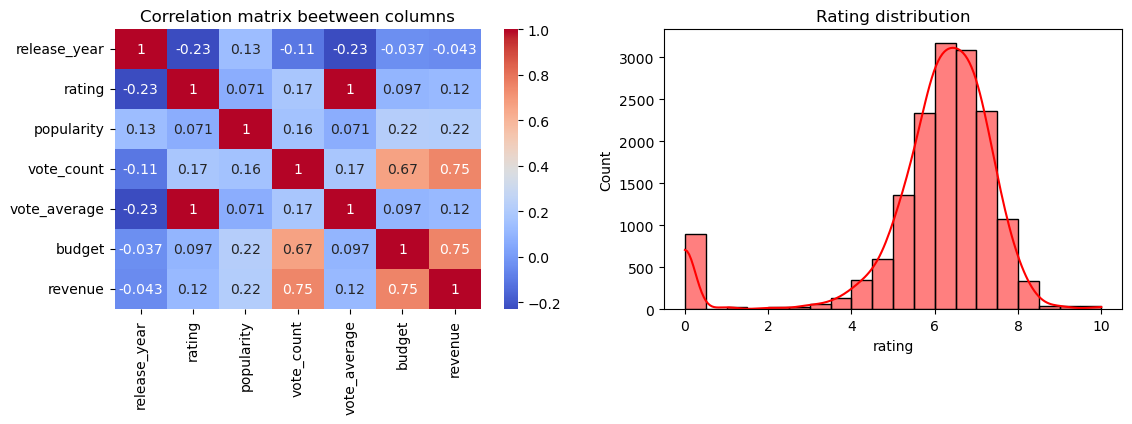

In [53]:
plt.figure(figsize=(13,8))
plt.subplot(221)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.subplot(222)
sns.histplot(df['rating'], bins=20, kde=True, color='red')
plt.title('Rating distribution')
plt.show()

Correlation beetween `vote_average` and `rating` is exactly 1 which means that it's probably duplicated and one should be removed.
Rating distribution histogram show a strong jump at rating equal to 0 which may mean no rating for this particular movie and should be trated as noise that may impact further analisys.

In [54]:
if 'vote_average' in df.columns: df.drop(columns=['vote_average'], inplace=True)
df = df[df['rating'] > 0]

df.describe(include=[float, int]).T

,count,mean,std,min,25%,50%,75%,max
release_year,15101.0,2.017104e+03,4.408496e+00,2010.00,2013.000,2017.00,2021.000,2.025000e+03
rating,15101.0,6.310965e+00,1.012144e+00,1.00,5.731,6.40,7.000,1.000000e+01
popularity,15101.0,2.090879e+01,7.052843e+01,3.86,7.951,11.08,17.753,3.876006e+03
vote_count,15101.0,7.614392e+02,2.133606e+03,1.00,66.000,154.00,459.000,3.711900e+04
budget,15101.0,9.131777e+06,2.940074e+07,0.00,0.000,0.00,3000000.000,4.600000e+08
revenue,15101.0,2.591508e+07,1.148104e+08,0.00,0.000,0.00,2334228.000,2.799439e+09


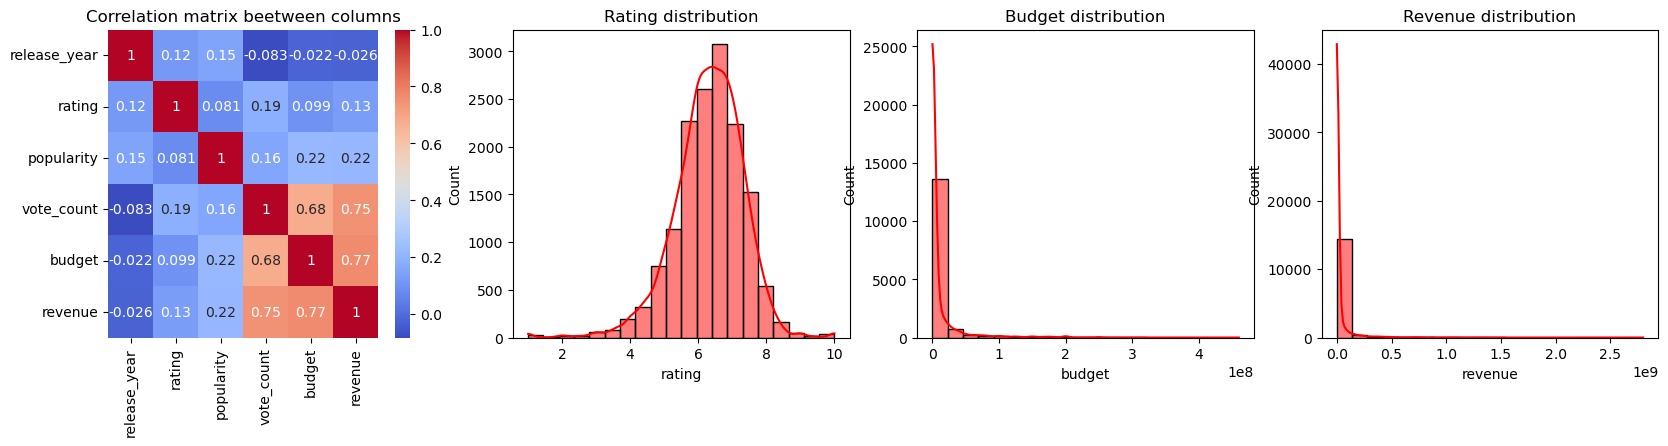

In [55]:
plt.figure(figsize=(20,4))
plt.subplot(141)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.subplot(142)
sns.histplot(df['rating'], bins=20, kde=True, color='red')
plt.title('Rating distribution')
plt.subplot(143)
sns.histplot(df['budget'], bins=20, kde=True, color='red')
plt.title('Budget distribution')
plt.subplot(144)
sns.histplot(df['revenue'], bins=20, kde=True, color='red')
plt.title('Revenue distribution')
plt.show()

Stron peak at o for `budget` and `revenue` may also mean missing data therefore they're removed from dataset

In [56]:
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
df.describe(include=[float, int]).T

,count,mean,std,min,25%,50%,75%,max
release_year,3539.0,2.016268e+03,4.279376e+00,2010.000,2013.000,2.016000e+03,2.019000e+03,2.025000e+03
rating,3539.0,6.535632e+00,7.734555e-01,1.899,6.025,6.598000e+00,7.100000e+00,8.600000e+00
popularity,3539.0,3.719364e+01,1.131520e+02,3.920,11.709,1.803600e+01,3.430250e+01,3.320616e+03
vote_count,3539.0,2.470031e+03,3.864416e+03,3.000,302.000,1.007000e+03,2.848500e+03,3.711900e+04
budget,3539.0,3.559219e+07,5.118976e+07,1.000,5942033.500,1.500000e+07,4.000000e+07,4.600000e+08
revenue,3539.0,1.038066e+08,2.178439e+08,2.000,4212487.000,2.380000e+07,9.516582e+07,2.799439e+09


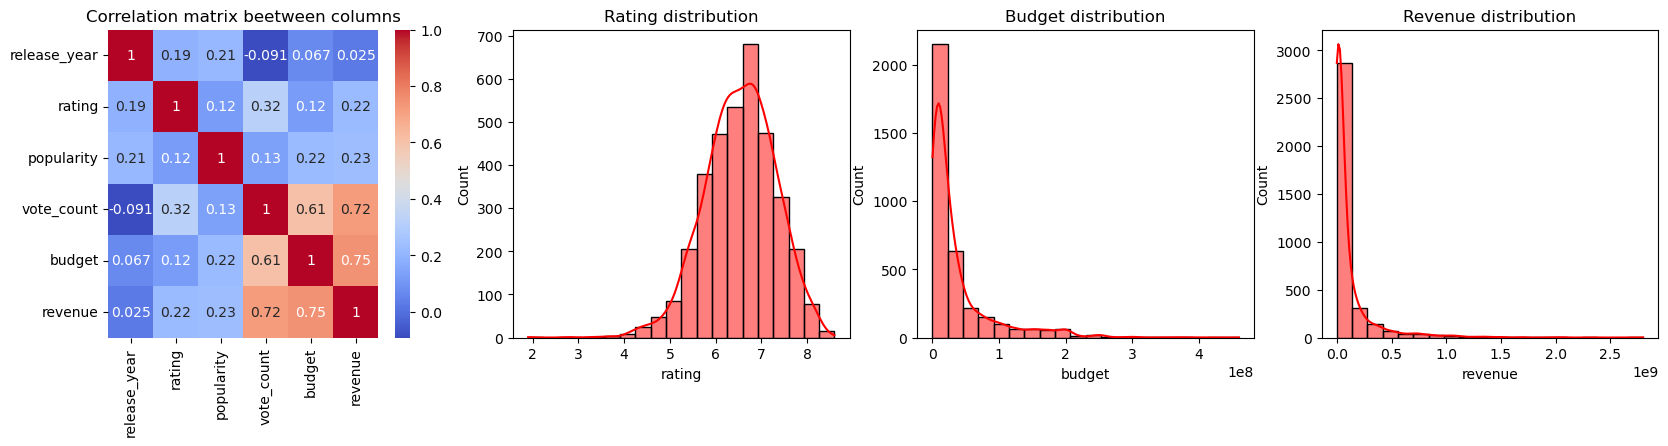

In [57]:
plt.figure(figsize=(20,4))
plt.subplot(141)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.subplot(142)
sns.histplot(df['rating'], bins=20, kde=True, color='red')
plt.title('Rating distribution')
plt.subplot(143)
sns.histplot(df['budget'], bins=20, kde=True, color='red')
plt.title('Budget distribution')
plt.subplot(144)
sns.histplot(df['revenue'], bins=20, kde=True, color='red')
plt.title('Revenue distribution')
plt.show()

`Seaborn.pairplot` visualizes pairwise relationships between variables in a dataset, creating a grid of plots.

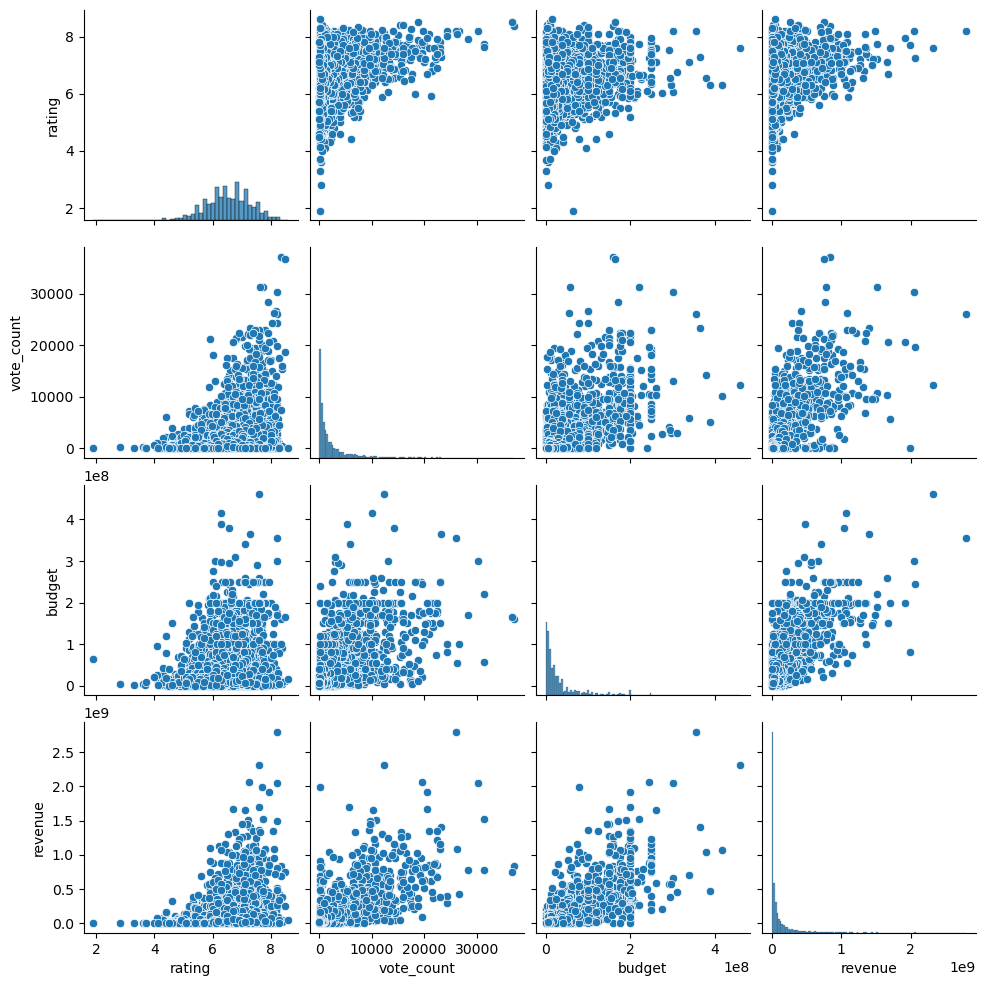

In [58]:
sns.pairplot(df.drop(columns=['release_year', 'popularity']))

Grouping data by budget using `pandas.qcut`

According to [pandas documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html): 
quantile-based discretization function. In case of `q=4` it's divided into 4 equal 'buckets' 

In [59]:
df['budget_range'] = pd.qcut(df['budget'], q=4, labels=['Low', 'Medium', 'High', 'Blockbuster'])
budget_analysis = df.groupby('budget_range')['rating'].mean()
print('Rating by budget:', budget_analysis)

Rating by budget: budget_range
Low            6.482597
Medium         6.514338
High           6.496823
Blockbuster    6.661464
Name: rating, dtype: float64


To analyze data by genres, a new dataset must be created using `DataFrame.groupby` method and math dunctions like `mean`.

In [60]:
df_genres = df.copy()
df_genres['genres'] = df['genres'].str.split(', ')
df_genres = df_genres.explode('genres')
df_genres['revenue_rate'] = df_genres['revenue'] / df_genres['budget'] 
genres_analisys = df_genres.groupby('genres').agg({
    'budget':       'mean',
    'revenue':      'mean',
    'revenue_rate': 'mean',
    'rating':       'mean',
    'genres':       'count'
}).rename(columns={'genres': 'movie_count'}).sort_values(by='rating', ascending=False)
print(genres_analisys.to_string())

                       budget       revenue  revenue_rate    rating  movie_count
genres                                                                          
Documentary      5.020385e+06  1.950980e+07  74453.324290  7.178030           33
History          2.950852e+07  5.827892e+07   1119.300165  6.939752          250
Animation        6.402196e+07  2.329761e+08    976.718845  6.903934          287
Music            2.957404e+07  8.815016e+07  23405.299183  6.886629          105
War              3.348168e+07  8.425703e+07      2.408097  6.846845          129
Drama            2.202513e+07  5.430036e+07    181.440455  6.717458         1661
Family           6.520024e+07  2.099631e+08      3.028069  6.683500          388
Western          4.313176e+07  7.734452e+07      1.770684  6.673471           34
Romance          2.251887e+07  6.348607e+07      3.083339  6.614200          484
Adventure        8.317343e+07  2.653370e+08      3.741807  6.613374          701
Crime            2.933510e+0

<Axes: title={'center': 'Mean budget and revenue over the years'}, xlabel='release_year'>

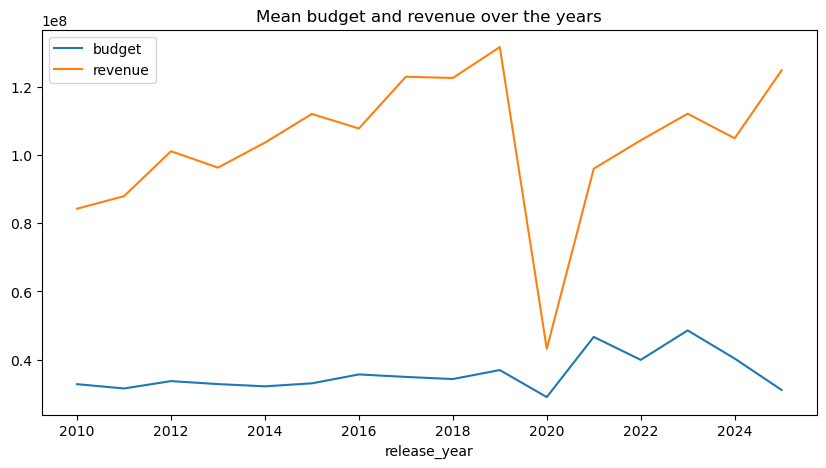

In [61]:
yearly_trends = df.groupby('release_year').agg({
    'budget':  'mean',
    'revenue': 'mean',
    'rating':  'mean'
})

# Wykres liniowy trendów
yearly_trends[['budget', 'revenue']].plot(figsize=(10,5), title='Mean budget and revenue over the years')